# Lesson 3. Regression

Date: 21.05.2026\
Author: *Andrey Zakharov*\
Extended by: *Matvey Bakshuk, FCS HSE*

## 1. Supervised learning

In this course we will work with **supervised** and **unsupervised** ML algorithms.

![](https://www.sharpsightlabs.com/wp-content/uploads/2021/04/supervised-learning-data_vs_unsupervised-learning-data.png)

In **supervised learning** the training data have **labels** (also called the *target* or *dependent variable*). The algorithm learns to predict these labels from other variables — called **features** (or *predictors*, *independent variables*). The target "supervises" the whole process:
- during training the algorithm adjusts its parameters to match the target, and
- after training we evaluate the model by comparing its predictions to the real target values.

![](https://www.sharpsightlabs.com/wp-content/uploads/2021/04/supervised-learning_target-supervises-process_visual-explanation.png)

In **unsupervised learning** data have no labels — only features. The algorithm looks for hidden structure on its own (e.g. clusters, latent dimensions). We will cover this later in the course.

| | Supervised | Unsupervised |
|---|---|---|
| **Has target?** | Yes | No |
| **Goal** | Predict target from features | Discover structure in features |
| **Evaluation** | Compare predictions to true labels | Domain-specific (silhouette, elbow, etc.) |
| **Examples** | Regression, classification | Clustering, dimensionality reduction |

### Regression vs Classification

Supervised learning splits into two major tasks depending on the type of the target variable:

- **Regression** — the target is **numeric** (continuous): income, temperature, test score, price.
- **Classification** — the target is **categorical**: spam/not-spam, species of flower, digit 0–9.

Today we focus on **regression**.

#### *What supervised learning tasks are these?*

1. Spam detection
2. Prediction of students' test grades (0–100 points scale)
3. Prediction of apartment prices
4. Handwritten digits recognition
5. Prediction of human age and gender based on a face image
6. Prediction of whether customers will cancel a subscription

## 2. The data

We will work with the **TIMSS 2019** dataset (Trends in International Mathematics and Science Study) — a large-scale international assessment of mathematics and science achievement of 8th-grade students.

Our goal: **predict mathematics achievement scores** (`bsmmat01`) from student-level features — attitudes, home resources, classroom climate, etc.

In [309]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
warnings.simplefilter("ignore")
%matplotlib inline

sns.set(style="darkgrid")

In [310]:
# If pyreadstat is not installed, uncomment the line below:
# !pip install pyreadstat

students = pd.read_spss("bsgrusm7.sav",
                       usecols=['IDSTUD', 'BSMMAT01', 'BSSSCI01', 'ITSEX', 'BSDAGE', 'BSBGHER',
                                'BSBGSSB', 'BSBGSB', 'BSBGICM', 'BSBGSLM', 'BSBGSVM', 'BSBGDML',
                                'BSBGSCM', 'BSBGSEC', 'BSDGEDUP', 'BSBG03', 'BSBG04'],
                       convert_categoricals=False)
students.head()

,IDSTUD,BSBG03,BSBG04,ITSEX,BSDAGE,BSMMAT01,BSSSCI01,BSBGHER,BSBGSSB,BSBGSB,BSBGSLM,BSBGICM,BSBGDML,BSBGSCM,BSBGSVM,BSBGSEC,BSDGEDUP
0,50010101.0,1.0,3.0,1.0,15.33,563.44456,614.96783,10.23835,7.08155,9.81861,9.68014,8.82274,9.71101,10.35323,6.25944,9.52551,2.0
1,50010102.0,1.0,2.0,2.0,14.42,653.28230,661.97837,10.26525,10.00496,10.41803,11.14859,11.65115,8.44435,12.13375,9.65438,8.99128,6.0
2,50010103.0,1.0,4.0,1.0,15.17,620.26477,645.97999,11.48712,10.70956,10.41803,11.42832,10.92487,11.10343,12.13375,11.30190,11.02143,1.0
3,50010104.0,2.0,2.0,2.0,15.17,507.10806,538.44693,8.99877,8.08091,12.93734,9.86638,7.98224,11.10343,8.51577,8.82228,9.52551,6.0
4,50010105.0,1.0,2.0,1.0,15.50,449.54188,537.33549,10.84499,8.08091,7.85954,9.68014,9.15605,8.95449,8.76168,8.57829,8.99128,1.0


**Variable descriptions:**

| Variable | Description |
|----------|-------------|
| `BSMMAT01` | Plausible value — Mathematics (our **target**) |
| `BSSSCI01` | Plausible value — Science |
| `ITSEX` | Sex (1 = Female, 2 = Male) |
| `BSDAGE` | Student age |
| `BSBGHER` | Home Educational Resources |
| `BSBGSSB` | Students' Sense of School Belonging |
| `BSBGSB` | Student Bullying |
| `BSBGICM` | Instructional Clarity in Maths Lessons |
| `BSBGSLM` | Students Like Learning Maths |
| `BSBGSVM` | Students Value Maths |
| `BSBGDML` | Disorderly Behaviour during Maths Lessons |
| `BSBGSCM` | Student Confident in Maths |
| `BSBGSEC` | Self-Efficacy for Computer Use |
| `BSDGEDUP` | Parents' Highest Education Level (1–6) |
| `BSBG03` | How often speak language of test at home (1–4) |
| `BSBG04` | Number of books at home (1–5) |

See the full codebook at [timss2019.org/international-database](https://timss2019.org/international-database/)

**Recode column names to lower case.** Which variables in the table above have a categorical scale?

In [311]:
#Your code here
students.rename(str.lower, axis='columns', inplace=True)
students.columns

Index(['idstud', 'bsbg03', 'bsbg04', 'itsex', 'bsdage', 'bsmmat01', 'bsssci01',
       'bsbgher', 'bsbgssb', 'bsbgsb', 'bsbgslm', 'bsbgicm', 'bsbgdml',
       'bsbgscm', 'bsbgsvm', 'bsbgsec', 'bsdgedup'],
      dtype='object')

**Recode the variables.**

- `itsex`: recode male (2) to 0 so that it becomes a binary 0/1 indicator (0 = male, 1 = female).
- `bsbg03`: collapse "almost always / sometimes / never" into 0 (= not always) vs 1 (= always).
- `bsdgedup`: group into three levels + NaN for "Don't Know".
- `bsbg04`: replace numeric codes with readable labels.

In [312]:
students.itsex.replace({2: 0}, inplace=True)
students.bsbg03.replace({2: 0, 3: 0, 4: 0}, inplace=True)
students.bsdgedup.replace({6: np.nan, 5: 'secondary', 4: 'secondary',
                           3: 'secondary', 2: 'postsecondary', 1: 'higher'}, inplace=True)
students.bsbg04.replace({1: 'books0_10', 2: 'books11_25', 3: 'books26_100',
                         4: 'books101_200', 5: 'books200more'}, inplace=True)

**Show descriptive statistics** for different types of variables.

In [313]:
#Your code here
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3901 entries, 0 to 3900
Data columns (total 17 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   idstud    3901 non-null   float64
 1   bsbg03    3893 non-null   float64
 2   bsbg04    3891 non-null   object 
 3   itsex     3901 non-null   float64
 4   bsdage    3901 non-null   float64
 5   bsmmat01  3901 non-null   float64
 6   bsssci01  3901 non-null   float64
 7   bsbgher   3893 non-null   float64
 8   bsbgssb   3887 non-null   float64
 9   bsbgsb    3884 non-null   float64
 10  bsbgslm   3886 non-null   float64
 11  bsbgicm   3887 non-null   float64
 12  bsbgdml   3885 non-null   float64
 13  bsbgscm   3886 non-null   float64
 14  bsbgsvm   3884 non-null   float64
 15  bsbgsec   3855 non-null   float64
 16  bsdgedup  3264 non-null   object 
dtypes: float64(15), object(2)
memory usage: 518.2+ KB


In [314]:
#Your code here
students.iloc[:, 1:].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
bsbg03,3893.0,0.79,0.40,0.00,1.00,1.00,1.00,1.00
itsex,3901.0,0.49,0.50,0.00,0.00,0.00,1.00,1.00
bsdage,3901.0,14.81,0.41,12.83,14.58,14.83,15.08,17.42
bsmmat01,3901.0,544.68,81.70,227.25,486.98,546.41,599.57,841.47
bsssci01,3901.0,543.51,74.46,230.35,494.62,547.52,593.42,793.42
bsbgher,3893.0,10.64,1.31,4.96,9.65,10.84,11.49,13.52
bsbgssb,3887.0,9.38,1.68,3.92,8.46,8.90,10.00,13.27
bsbgsb,3884.0,10.33,1.82,1.95,9.05,9.93,11.19,12.94
bsbgslm,3886.0,9.95,1.50,5.09,8.95,9.87,10.77,13.85
bsbgicm,3887.0,9.95,1.73,3.70,8.82,9.93,10.92,13.02


In [315]:
students.describe(include='object').T

,count,unique,top,freq
bsbg04,3891,5,books11_25,1342
bsdgedup,3264,3,higher,1731


**Show N of missing data** by variable and drop missing observations.

In [316]:
students.isna().sum()

idstud        0
bsbg03        8
bsbg04       10
itsex         0
bsdage        0
bsmmat01      0
bsssci01      0
bsbgher       8
bsbgssb      14
bsbgsb       17
bsbgslm      15
bsbgicm      14
bsbgdml      16
bsbgscm      15
bsbgsvm      17
bsbgsec      46
bsdgedup    637
dtype: int64

In [317]:
students.dropna(inplace=True)
students.shape

(3203, 17)

**Visualise the target distribution.** A roughly symmetric, unimodal distribution is ideal for linear regression. Heavy skew or multiple modes may require transformation or a different approach.

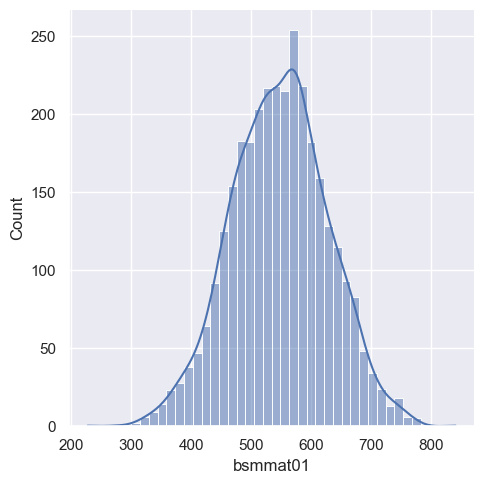

In [318]:
#Your code here
sns.displot(students, x='bsmmat01', kde=True);

**Explore feature–target relationships.** Before modelling, check which features correlate with math scores.

In [319]:
students2 = students.copy()
students2.drop(columns='idstud', inplace=True)
y = students2.bsmmat01
X = students2.drop(columns=['bsmmat01', 'bsdgedup', 'bsbg04'])
y.shape, X.shape

((3203,), (3203, 13))

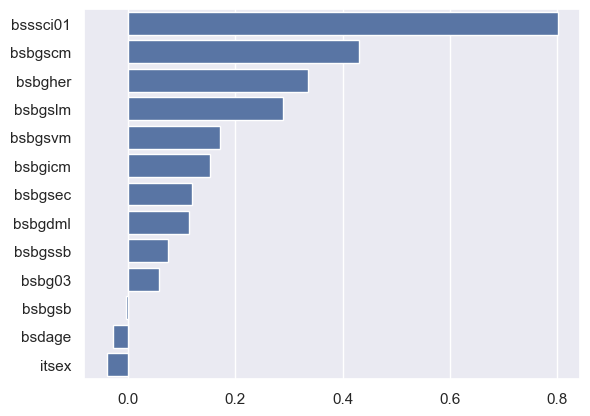

In [320]:
correlations = X.corrwith(y).sort_values(ascending=False)
sns.barplot(y=correlations.index, x=correlations)
plt.xlabel('')
plt.ylabel('');

**Scatter plots** for the four features most correlated with math scores.

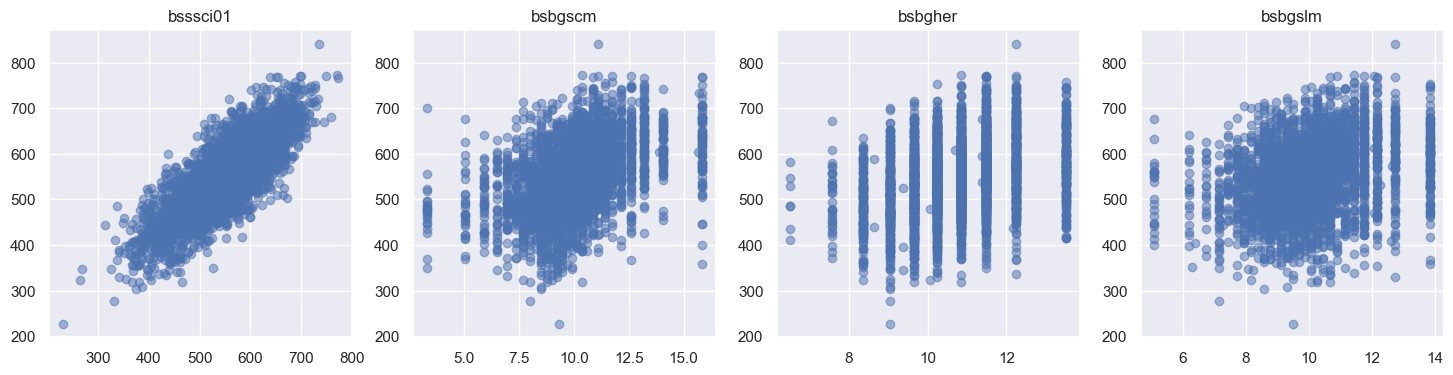

In [321]:
#Your code here
fig, ax = plt.subplots(figsize=(18, 4), ncols=4)
for i, feature in enumerate(['bsssci01', 'bsbgscm', 'bsbgher', 'bsbgslm']):
    ax[i].scatter(X[feature], y, alpha=0.5)
    ax[i].set_title(feature)
plt.show()

## 3. Linear regression — a brief reminder

You are already familiar with linear regression from other courses, so here is a compact refresher.

The model predicts the target as a **weighted sum** of features plus an intercept:

$$\hat{y}_i = b_0 + b_1 x_{1,i} + \ldots + b_k x_{k,i}$$

- $\hat{y}_i$ — predicted value for observation $i$
- $b_0$ — intercept (bias term)
- $b_1, \ldots, b_k$ — feature weights (coefficients)

In vectorised form: $\hat{y} = Xb$, where $X$ is the feature matrix with a column of ones prepended.

Each coefficient $b_j$ tells us: *"holding all other features constant, a one-unit increase in $x_j$ is associated with a $b_j$-unit change in $\hat{y}$."*

![](https://media.geeksforgeeks.org/wp-content/uploads/20231129130431/11111111.png)

### Fitting the model with scikit-learn

`sklearn.linear_model.LinearRegression` fits the model using the **Ordinary Least Squares** (OLS) method. The key attributes after fitting:
- `.coef_` — the vector of feature weights $[b_1, \ldots, b_k]$
- `.intercept_` — the bias term $b_0$

In [322]:
from sklearn.linear_model import LinearRegression

lr1 = LinearRegression().fit(X, y)
print("lr.coef_:", lr1.coef_)
print("lr.intercept_:", lr1.intercept_)

lr.coef_: [-1.76567267  2.02161304 -2.59910962  0.79808212  3.47750624 -0.10201224
 -2.55760579  5.90443633 -1.27486029  0.96816913  5.49494057 -0.92902894
  0.57037137]
lr.intercept_: 32.33308074232161


## 4. Loss function and performance metrics

To **train** a model means to find parameters that minimise some measure of prediction error.

### Loss function vs cost function

- **Loss function** — measures the error for a *single* observation: $(y_i - \hat{y}_i)^2$
- **Cost function** — the *average* loss across all observations.

In linear regression the cost function is the **Mean Squared Error**:

$$\text{MSE} = \frac{1}{N}\sum_{i=1}^{N}(y_i - \hat{y}_i)^2 \longrightarrow \min$$

The coefficients that minimise MSE can be found analytically via the **Normal Equation**:

$$\vec{b} = (X^T X)^{-1} X^T y$$

This is exactly what `LinearRegression().fit()` computes.

### Performance metrics

After fitting, we need to quantify how well the model predicts. Several complementary metrics exist:

**Mean Absolute Error** — average absolute deviation, in the same units as the target:
$$\text{MAE} = \frac{1}{N}\sum|y_i - \hat{y}_i|$$

**Mean Squared Error** — penalises large errors more heavily (because of squaring):
$$\text{MSE} = \frac{1}{N}\sum(y_i - \hat{y}_i)^2$$

**Root Mean Squared Error** — same as MSE but back in original units:
$$\text{RMSE} = \sqrt{\text{MSE}}$$

![](https://248006.selcdn.ru/public/Data-science-4/img/rmse_vs_mae.png)

> **When to prefer which?** MSE/RMSE penalise large errors quadratically — good when outliers matter. MAE is more robust to outliers. In practice, report both.

**Coefficient of determination** $R^2$ — you already know this one. A quick reminder:

$$R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

$R^2$ shows the **proportion of variance in the target explained by the model**. It ranges from 0 to 1 (for in-sample), making it easy to compare different models regardless of the target's scale. Unlike MAE/RMSE, $R^2$ is *normalised* — a value of 0.68 means "the model explains 68% of the variance".

| Metric | Units | Range | Outlier-sensitive? |
|--------|-------|-------|-------------------|
| MAE | Same as target | $[0, +\infty)$ | Less |
| MSE | Squared units | $[0, +\infty)$ | More |
| RMSE | Same as target | $[0, +\infty)$ | More |
| $R^2$ | Dimensionless | $(-\infty, 1]$ | More |

In [323]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = lr1.predict(X)

print(f"MAE  = {mean_absolute_error(y, y_pred):.2f}")
print(f"MSE  = {mean_squared_error(y, y_pred):.2f}")
print(f"RMSE = {np.sqrt(mean_squared_error(y, y_pred)):.2f}")
print(f"R²   = {r2_score(y, y_pred):.2f}")

MAE  = 35.94
MSE  = 2051.19
RMSE = 45.29
R²   = 0.68


### A note on p-values: `sklearn` vs `statsmodels`

After looking at MAE/MSE/RMSE/R², a natural next question is: *"which coefficients are statistically significant?"* — i.e. where are the p-values? If you look carefully at `LinearRegression` in scikit-learn, you will not find them. This is not an oversight — it reflects a deliberate design choice. Understanding it will help you pick the right tool for each job.

**Two philosophies, two libraries.** Python has two mainstream OLS implementations, and they optimise for different goals:

| | `statsmodels.OLS` | `sklearn.LinearRegression` |
|---|---|---|
| Primary goal | **Inference** — explain relationships | **Prediction** — minimise out-of-sample error |
| Output | Coefficients, std. errors, *t*- and *p*-values, confidence intervals, $R^2$, AIC/BIC, diagnostic tests | `.coef_`, `.intercept_`, `.predict()` |
| Intercept | Added manually via `sm.add_constant(X)` | Added automatically (`fit_intercept=True`) |
| Typical workflow | `.summary()` — one-shot regression report | `.fit()` → `.predict()` → cross-validate |
| Core assumption | Classical OLS assumptions must hold | Works on any data; evaluated by held-out error |

**Why doesn't sklearn print p-values?** scikit-learn is built for predictive modelling on large datasets, and with a Large N statistical significance tend to be not as meaningful (it is more likely that coefficient would be statistically significant without a real effect on the large N). Printing a *p*-value there would give a number that looks authoritative but is not actually valid. 

`statsmodels`, in contrast, is designed for econometrics and applied statistics — contexts where you *want* to test whether a coefficient is significantly different from zero, and where you are willing to check the assumptions.

**A quick `statsmodels` example** — if you do want the inference report:

```python
import statsmodels.api as sm
X_const = sm.add_constant(X)          # don't forget the intercept column!
ols = sm.OLS(y, X_const).fit()
print(ols.summary())
```

The deeper point: *statistical significance* and *predictive usefulness* are related but not identical. A coefficient can be highly significant yet explain almost nothing ($R^2 \approx 0$); a tree-based model can predict beautifully without a single p-value in sight. Knowing which question you are answering is half the job.

With that in mind, we now turn to the diagnostics that tell us whether the OLS assumptions actually hold for our model — starting with the residuals.


## 5. Residual analysis

Metrics give us a single number summarising the overall fit. **Residual plots** reveal *how* the model fails — are there patterns in the errors, or are they randomly scattered?

A **residual** is the difference between the observed and predicted value:

$$e_i = y_i - \hat{y}_i$$

If the model is well-specified, residuals should look like **random noise**:
- No systematic pattern when plotted against predicted values
- Roughly normally distributed
- Constant spread (homoscedasticity)

| Plot | What it checks | Red flag |
|------|---------------|----------|
| Residuals vs Predicted | Linearity, homoscedasticity | Funnel shape, curved pattern |
| QQ-plot of residuals | Normality of errors | Points deviating from the diagonal |
| Histogram of residuals | Distribution shape | Heavy skew, multiple modes |

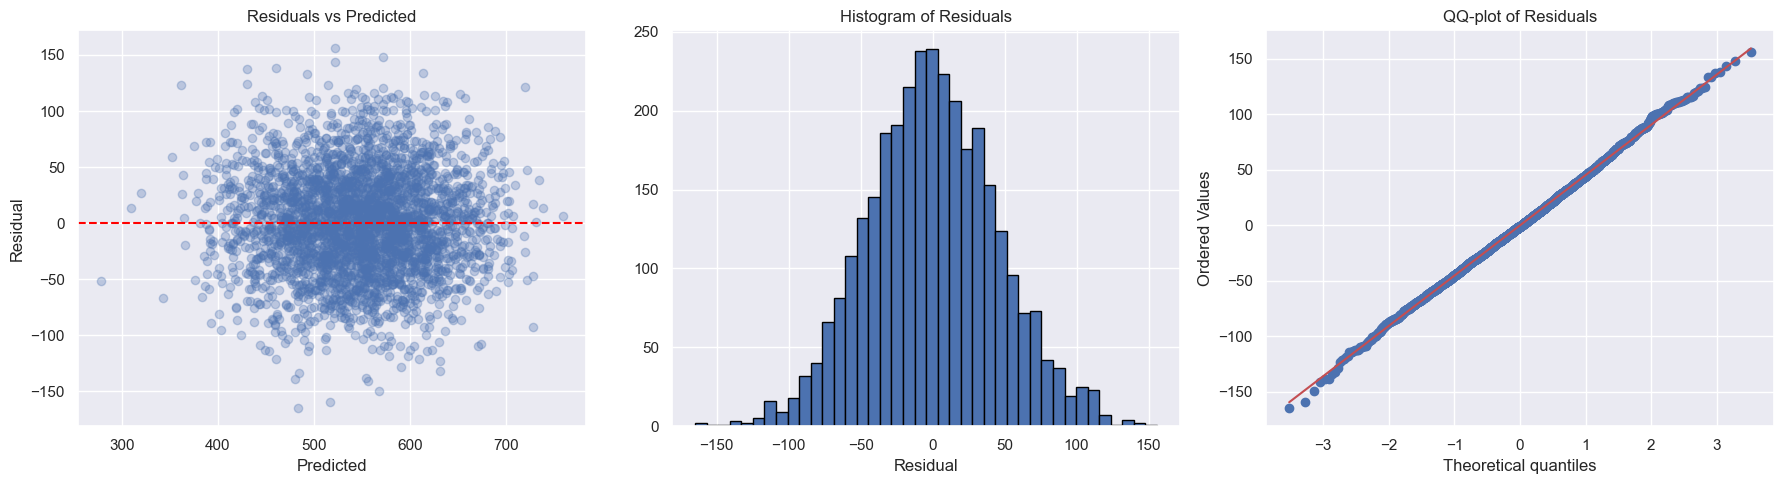

In [324]:
residuals = y - y_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Residuals vs Predicted
axes[0].scatter(y_pred, residuals, alpha=0.3)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted')

# 2. Histogram of residuals
axes[1].hist(residuals, bins=40, edgecolor='black')
axes[1].set_xlabel('Residual')
axes[1].set_title('Histogram of Residuals')

# 3. QQ-plot
from scipy import stats
stats.probplot(residuals, dist='norm', plot=axes[2])
axes[2].set_title('QQ-plot of Residuals')

plt.tight_layout()
plt.show()

**Interpreting the plots:**

- **Residuals vs Predicted:** if the cloud is roughly symmetric around zero with constant spread — good. A funnel shape (spread increasing with predicted value) signals **heteroscedasticity**. A curved pattern signals **non-linearity**.
- **QQ-plot:** if points lie close to the diagonal — residuals are approximately normal. Deviations at the tails are common and usually acceptable.
- **Histogram:** complements the QQ-plot — gives a quick sense of the overall shape.

## 6. Multicollinearity

When we interpret regression coefficients, we assume each weight reflects the *unique* contribution of that feature. But what if two features are highly correlated with each other? In this situation — called **multicollinearity** — individual coefficient values become **unstable**: they can flip sign or change magnitude dramatically when a feature is added or removed.

The model's *predictions* may still be fine, but *interpreting* individual weights becomes unreliable.

### Variance Inflation Factor (VIF)

VIF quantifies how much a feature's coefficient variance is "inflated" due to correlation with other features:

$$\text{VIF}_j = \frac{1}{1 - R^2_j}$$

where $R^2_j$ is obtained by regressing feature $j$ on all other features.

| VIF | Interpretation |
|-----|---------------|
| 1 | No collinearity |
| 1–5 | Moderate — usually acceptable |
| 5–10 | High — coefficients may be unreliable |
| >10 | Severe — consider removing or combining features |

In [325]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data.sort_values('VIF', ascending=False).round(2)

,feature,VIF
2,bsdage,151.61
7,bsbgslm,119.95
4,bsbgher,81.05
3,bsssci01,71.15
10,bsbgscm,58.44
8,bsbgicm,55.65
5,bsbgssb,49.66
11,bsbgsvm,43.72
6,bsbgsb,41.92
9,bsbgdml,35.06


> **What to do about high VIF?** Several options: (1) remove one of the correlated features, (2) combine them (e.g. PCA), or (3) use **regularisation** (Ridge/Lasso) — we will cover this in Section 11.

## 7. Model evaluation

So far we evaluated the model on the **same data** it was trained on. This is optimistic — the model has already "seen" these observations. What we really care about is how well it **generalises** to new, unseen data.

### Train–test split (holdout)

The simplest approach: hold out part of the data, train on the rest, evaluate on the held-out portion.

```
Full data
├── Training set (e.g. 70%) → fit the model
└── Test set (e.g. 30%)     → evaluate generalization
```

The test set error is our estimate of the **generalization error** (or *out-of-sample error*).

> **Important:** the test set should be used **only once**, at the very end. If you tune hyperparameters based on the test set, it is no longer a fair estimate of generalization.

In [326]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)

**Fit the regression and show metrics on both sets.**

If the model generalises well, train and test metrics should be close. If the test error is much higher, the model may be **overfitting**.

In [327]:
lr2 = LinearRegression().fit(X_train, y_train)

y_pred_train = lr2.predict(X_train)
y_pred_test = lr2.predict(X_test)

def metrics(y_true, y_pred):
    print(f'MAE  = {mean_absolute_error(y_true, y_pred):.3f}')
    print(f'MSE  = {mean_squared_error(y_true, y_pred):.3f}')
    print(f'RMSE = {np.sqrt(mean_squared_error(y_true, y_pred)):.3f}')
    print(f'R²   = {r2_score(y_true, y_pred):.3f}')

print('On train:')
metrics(y_train, y_pred_train)
print('\nOn test:')
metrics(y_test, y_pred_test)

On train:
MAE  = 35.805
MSE  = 2027.459
RMSE = 45.027
R²   = 0.677

On test:
MAE  = 36.421
MSE  = 2122.482
RMSE = 46.070
R²   = 0.694


### Cross-validation

A single train–test split can be **lucky or unlucky** — the result depends on which observations ended up in which set. **Cross-validation** solves this by repeating the split multiple times.

In **k-fold cross-validation**:
1. Split the training data into $k$ roughly equal parts ("folds").
2. For each fold: train on the other $k-1$ folds, evaluate on the held-out fold.
3. Average the $k$ evaluation scores.

![](https://scikit-learn.org/stable/_images/grid_search_cross_validation.png)

This gives a **more stable and reliable** estimate of model performance than a single split.

In [328]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(lr2, X_train, y_train, cv=10, scoring="neg_root_mean_squared_error")
print("Cross validation scores:")
for s in cv_scores:
    print(f"\t{s:.3f}")
print(f"\nMean CV RMSE = {np.mean(-cv_scores):.4f}")

Cross validation scores:
	-48.921
	-47.616
	-46.767
	-41.086
	-44.539
	-45.326
	-45.270
	-40.928
	-45.932
	-46.569

Mean CV RMSE = 45.2954


> **Note:** sklearn's scoring functions are *maximised*, so error metrics are returned as **negative** values (e.g. `neg_root_mean_squared_error`). We negate them when reporting.

## 8. Feature scaling and coefficient interpretation

**Problem:** our features have very different scales — `bsssci01` ranges from ~230 to ~800, while `itsex` is 0/1. This makes raw coefficients **incomparable** — a large coefficient may simply mean the feature has small values, not that it is more important.

**Solution:** **standardisation** transforms each feature to have mean = 0 and std = 1:

$$x'_j = \frac{x_j - \bar{x}_j}{\sigma_{x_j}}$$

After standardisation, all coefficients are in the same units (standard deviations), and their magnitudes are directly comparable.

> **Important:** fit the scaler on the **training set only**, then apply it to the test set. This prevents information leakage from the test set.

In [329]:
def show_weights(features, weights, means, scales):
    fig, axs = plt.subplots(figsize=(14, 10), ncols=3)
    sorted_weights = sorted(zip(weights, features, means, scales), reverse=True)
    weights, features, means, scales = zip(*sorted_weights)
    features = list(features)

    sns.barplot(y=features, x=list(weights), ax=axs[0])
    axs[0].set_xlabel('Weight')
    sns.barplot(y=features, x=list(means), ax=axs[1])
    axs[1].set_xlabel('Mean')
    sns.barplot(y=features, x=list(scales), ax=axs[2])
    axs[2].set_xlabel('Scale')
    plt.tight_layout()

**Before scaling** — coefficients on the raw scale. Notice how the magnitudes depend on the feature's range.

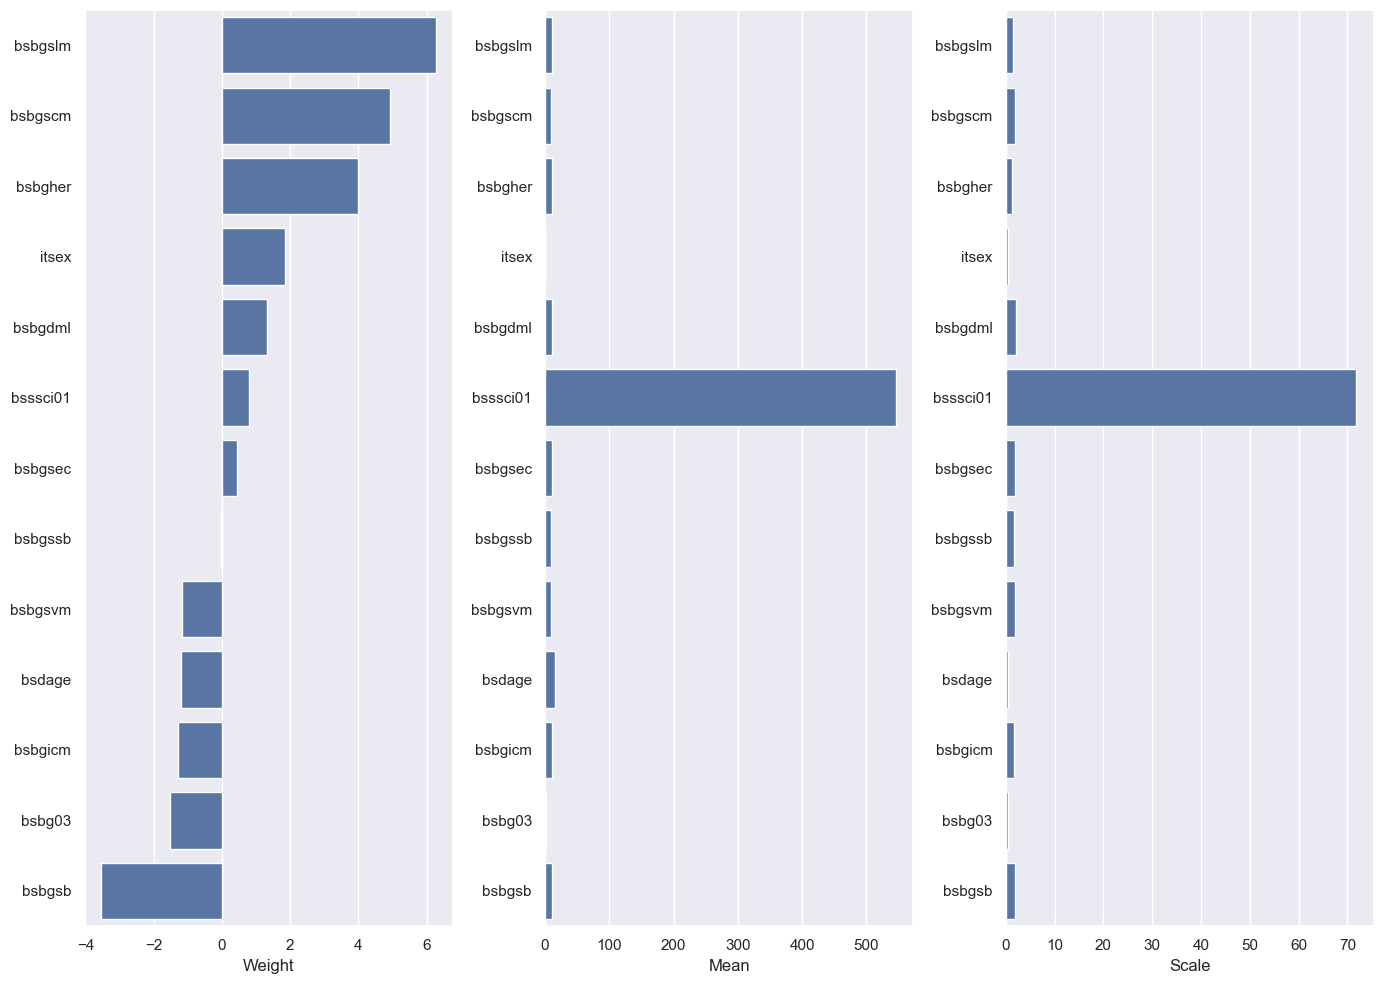

In [330]:
numeric_features = X.columns
means = pd.Series(data=X_train.mean(axis=0), index=numeric_features)
scales = pd.Series(data=X_train.std(axis=0), index=numeric_features)
show_weights(numeric_features, lr2.coef_, means, scales)

**After scaling** — coefficients in standardised units. Now we can compare their magnitudes directly.

In [331]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr3 = LinearRegression().fit(X_train_scaled, y_train)

y_pred_train = lr3.predict(X_train_scaled)
y_pred_test = lr3.predict(X_test_scaled)

print('On train:')
metrics(y_train, y_pred_train)
print('\nOn test:')
metrics(y_test, y_pred_test)

On train:
MAE  = 35.805
MSE  = 2027.459
RMSE = 45.027
R²   = 0.677

On test:
MAE  = 36.421
MSE  = 2122.482
RMSE = 46.070
R²   = 0.694


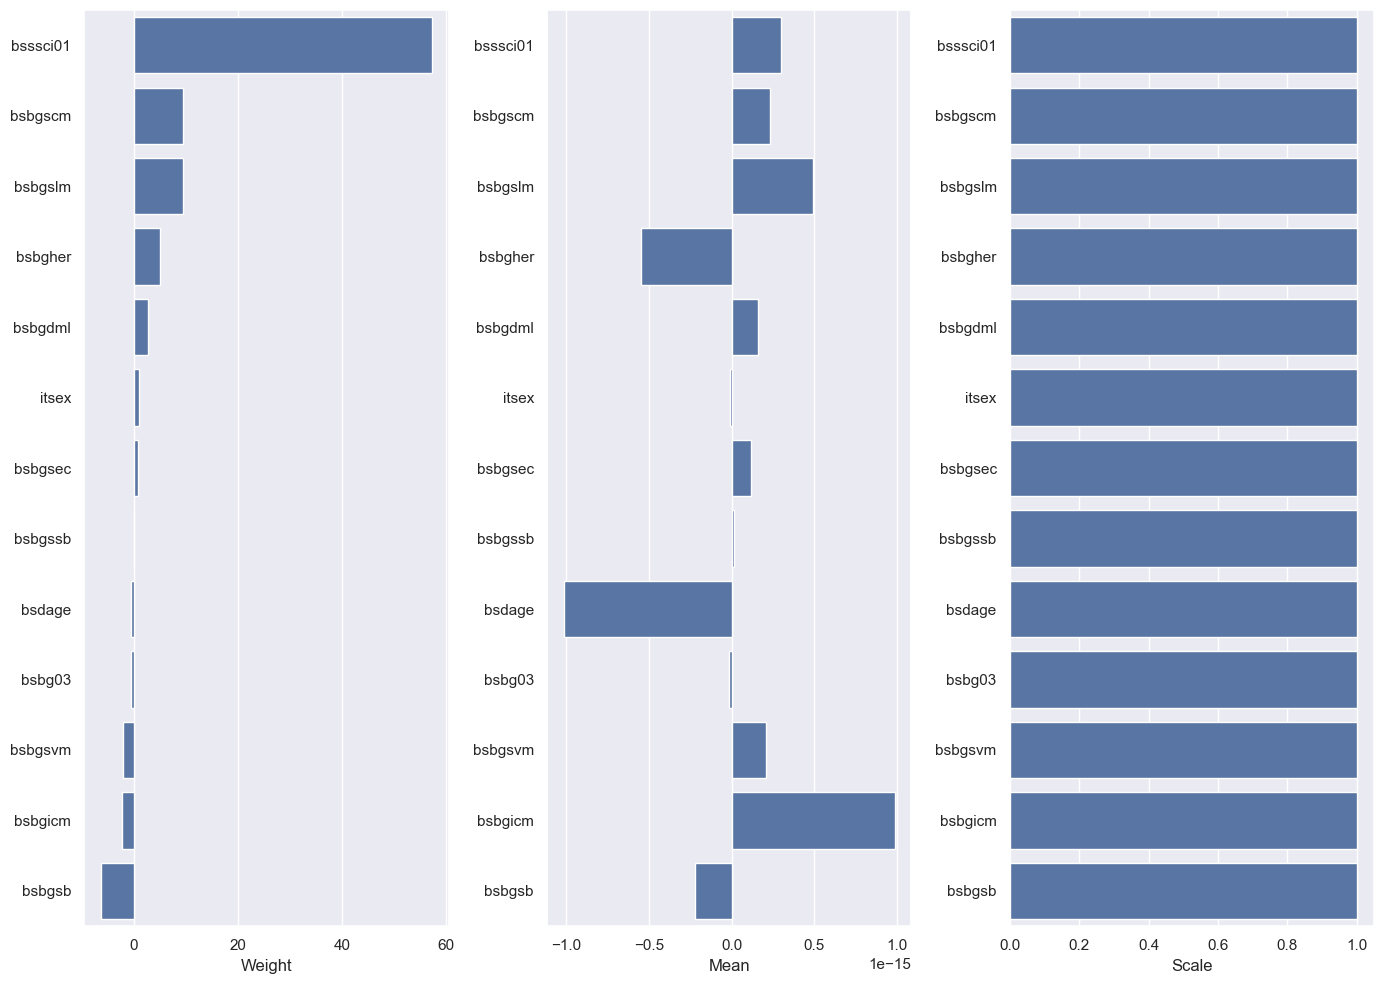

In [332]:
means = pd.Series(data=X_train_scaled.mean(axis=0), index=numeric_features)
scales = pd.Series(data=X_train_scaled.std(axis=0), index=numeric_features)
show_weights(numeric_features, lr3.coef_, means, scales)

Notice: the metrics are **identical** before and after scaling — standardisation does not change the model's predictions, only the *interpretation* of individual coefficients.

## 9. Polynomial regression

Linear regression fits a *straight line* (or hyperplane). But what if the true relationship is curved?

**Polynomial regression** adds transformed features — squares, cubes, and cross-products — so the model can capture non-linear patterns while still being "linear in parameters":

$$\hat{y} = b_0 + b_1 x + b_2 x^2 + b_3 x^3 + \ldots$$

In sklearn this is done by first creating polynomial features with `PolynomialFeatures`, then fitting a regular `LinearRegression`.

### Demo: fitting polynomials of different degree

Below we generate data from a known function $y = \cos(1.5\pi x)$ and fit polynomials of degree 1, 4, and 20. Watch what happens as complexity increases.

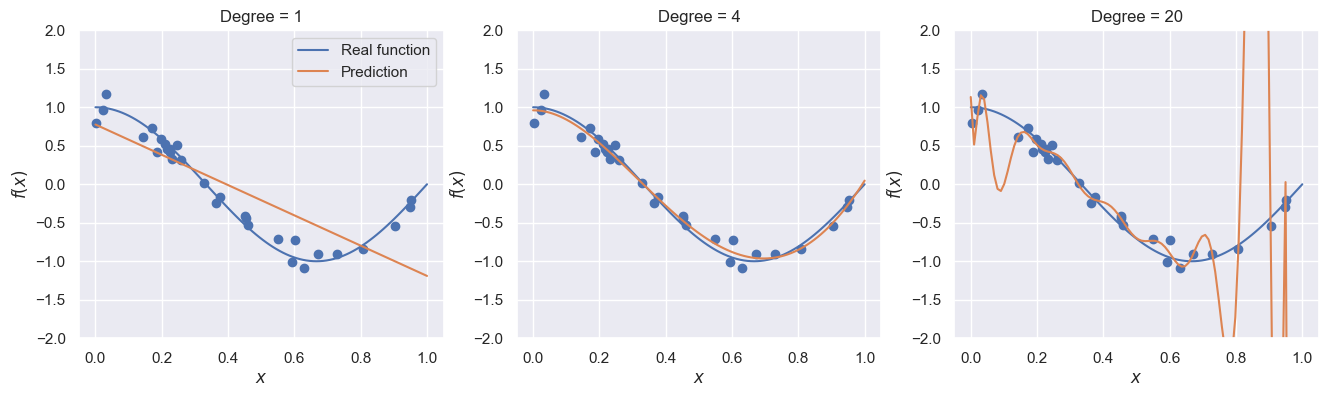

In [333]:
from sklearn.preprocessing import PolynomialFeatures

np.random.seed(36)
x = np.linspace(0, 1, 100)
y_true = np.cos(1.5 * np.pi * x)

x_objects = np.random.uniform(0, 1, size=30)
y_objects = np.cos(1.5 * np.pi * x_objects) + np.random.normal(scale=0.1, size=x_objects.shape)

fig, axs = plt.subplots(figsize=(16, 4), ncols=3)
for i, degree in enumerate([1, 4, 20]):
    X_obj = PolynomialFeatures(degree, include_bias=False).fit_transform(x_objects[:, None])
    X_line = PolynomialFeatures(degree, include_bias=False).fit_transform(x[:, None])
    regr = LinearRegression().fit(X_obj, y_objects)
    y_line = regr.predict(X_line)
    axs[i].plot(x, y_true, label='Real function')
    axs[i].scatter(x_objects, y_objects)
    axs[i].plot(x, y_line, label='Prediction')
    if i == 0:
        axs[i].legend()
    axs[i].set_title(f'Degree = {degree}')
    axs[i].set_xlabel('$x$')
    axs[i].set_ylabel('$f(x)$')
    axs[i].set_ylim(-2, 2)

- **Degree 1** (underfitting): too simple — misses the curvature.
- **Degree 4** (good fit): captures the pattern without chasing noise.
- **Degree 20** (overfitting): memorises the training points, wild oscillations between them.

Let's see what happens to the coefficients as degree increases:

In [334]:
regr.coef_  # degree=20 coefficients

array([-1.79051253e+02,  1.67579088e+04, -6.05610111e+05,  1.13126373e+07,
       -1.27416024e+08,  9.41286408e+08, -4.78019902e+09,  1.70735414e+10,
       -4.29674199e+10,  7.41852766e+10, -8.01088978e+10,  3.51190783e+10,
        3.21459736e+10, -5.32577030e+10,  1.03811221e+10,  3.64047164e+10,
       -3.91294244e+10,  1.68496875e+10, -2.67247751e+09, -6.78693073e+07])

The coefficients are **enormous** — a hallmark of overfitting. The model is fitting noise, not signal.

The **norm** (length) of the coefficient vector measures overall model complexity:

$$\|w\| = \sqrt{w_1^2 + \ldots + w_n^2}$$

### Polynomial features on the TIMSS data

Now let's add polynomial terms to our student model and track train/test error across degrees 1–3.

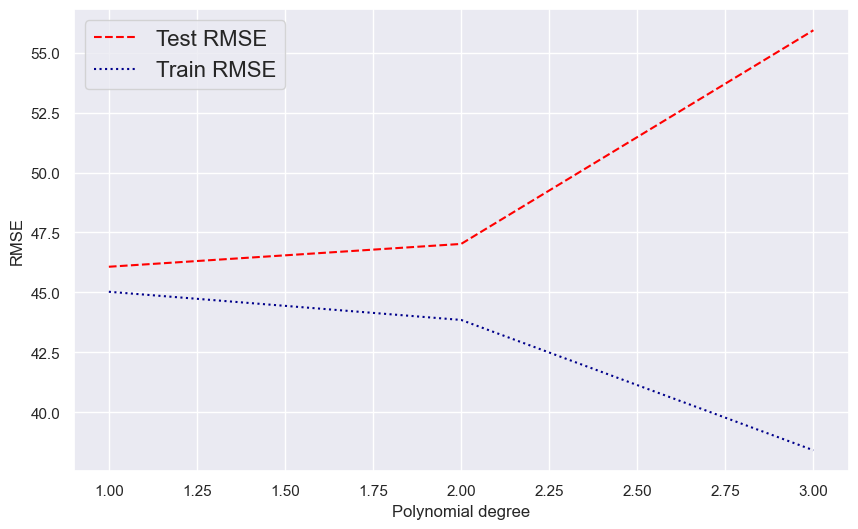

In [335]:
from numpy.linalg import norm

degrees = []
test_errors = []
train_errors = []
w_norms = []

for i in range(1, 4):
    poly = PolynomialFeatures(degree=i, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_scaled)
    X_test_poly = poly.transform(X_test_scaled)

    lr_p = LinearRegression().fit(X_train_poly, y_train)
    y_train_pred = lr_p.predict(X_train_poly)
    y_test_pred = lr_p.predict(X_test_poly)

    degrees.append(i)
    test_errors.append(np.sqrt(mean_squared_error(y_test, y_test_pred)))
    train_errors.append(np.sqrt(mean_squared_error(y_train, y_train_pred)))
    w_norms.append(norm(lr_p.coef_))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(degrees, test_errors, 'k--', c='red', label='Test RMSE')
ax.plot(degrees, train_errors, 'k:', c='darkblue', label='Train RMSE')
ax.legend(loc='upper left', fontsize=16)
plt.xlabel('Polynomial degree')
plt.ylabel('RMSE')
plt.show()

In [336]:
print('Coefficient vector norms by degree:')
for d, w in zip(degrees, w_norms):
    print(f'  Degree {d}: ||w|| = {w:.1f}')

Coefficient vector norms by degree:
  Degree 1: ||w|| = 59.6
  Degree 2: ||w|| = 60.8
  Degree 3: ||w|| = 59.7


As polynomial degree grows, train error drops but test error increases — the model is **overfitting**.

## 10. Bias–variance tradeoff

The polynomial experiment above illustrates a fundamental concept in machine learning: the **bias–variance tradeoff**.

Every model's prediction error can be decomposed into three parts:

$$\text{Total Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Noise}$$

| Term | Meaning | In polynomial example |
|------|---------|----------------------|
| **Bias** | Error from wrong assumptions (model too simple) | Degree 1: can't capture curvature |
| **Variance** | Error from sensitivity to training data (model too complex) | Degree 20: fits noise, changes wildly with different samples |
| **Noise** | Inherent randomness in the data — cannot be reduced | Always present |

![](https://scott.fortmann-roe.com/docs/docs/BiasVariance/biasvariance.png)

- **Underfitting** (high bias): the model is too simple to capture the true pattern. Both train and test errors are high.
- **Overfitting** (high variance): the model memorises training noise. Train error is low, test error is high.
- **Sweet spot**: the model is complex enough to capture the signal but not so complex that it fits noise.

The goal of **regularisation** (next section) is to push a complex model back toward this sweet spot.

## 11. Overfitting and regularisation

Regularisation **constrains** the model to prevent overfitting. The idea: add a penalty to the cost function that discourages large coefficients.

The fewer degrees of freedom the model has, the harder it is for it to overfit.

### 11.1. Ridge regression ($L_2$ regularisation)

Ridge adds a penalty proportional to the **squared magnitude** of the coefficients:

$$L_{\text{Ridge}} = \sum_{i=1}^{N}(y_i - \hat{y}_i)^2 + \alpha \cdot \sum_{j=1}^{k} w_j^2 = \text{MSE} + \alpha \cdot \|w\|^2$$

- $\alpha \ge 0$ is the **regularisation strength** (hyperparameter).
- Larger $\alpha$ → coefficients are **shrunk** more towards zero → simpler model.
- $\alpha = 0$ → ordinary linear regression.

Ridge **shrinks** all coefficients but never sets them exactly to zero — all features remain in the model.

> **Why scaling matters:** the penalty $\sum w_j^2$ treats all coefficients equally. If features have different scales, a feature with large values will have a small $w_j$ and be penalised less. Always standardise features before applying Ridge (or Lasso).

In [337]:
from sklearn.linear_model import Ridge

ridge = Ridge().fit(X_train_scaled, y_train)
y_test_pred = ridge.predict(X_test_scaled)
y_train_pred = ridge.predict(X_train_scaled)

print('Train RMSE = %.4f' % np.sqrt(mean_squared_error(y_train, y_train_pred)))
print('Test RMSE  = %.4f' % np.sqrt(mean_squared_error(y_test, y_test_pred)))

Train RMSE = 45.0273
Test RMSE  = 46.0700


**Finding the best $\alpha$** using `GridSearchCV` — an exhaustive search over a grid of candidates, evaluated via cross-validation.

Best alpha = 9.4120


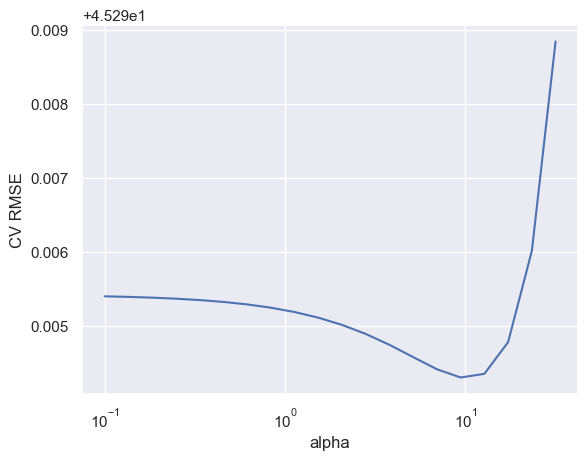

In [338]:
from sklearn.model_selection import GridSearchCV

alphas = np.logspace(-1, 1.5, 20)
searcher = GridSearchCV(Ridge(),
                        {'alpha': alphas},
                        scoring='neg_root_mean_squared_error',
                        cv=10)
searcher.fit(X_train_scaled, y_train)

best_alpha = searcher.best_params_['alpha']
print(f'Best alpha = {best_alpha:.4f}')

plt.plot(alphas, -searcher.cv_results_['mean_test_score'])
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('CV RMSE');

In [339]:
ridge2 = Ridge(alpha=best_alpha).fit(X_train_scaled, y_train)
y_test_pred = ridge2.predict(X_test_scaled)
y_train_pred = ridge2.predict(X_train_scaled)

print('Train RMSE = %.4f' % np.sqrt(mean_squared_error(y_train, y_train_pred)))
print('Test RMSE  = %.4f' % np.sqrt(mean_squared_error(y_test, y_test_pred)))

Train RMSE = 45.0281
Test RMSE  = 46.0675


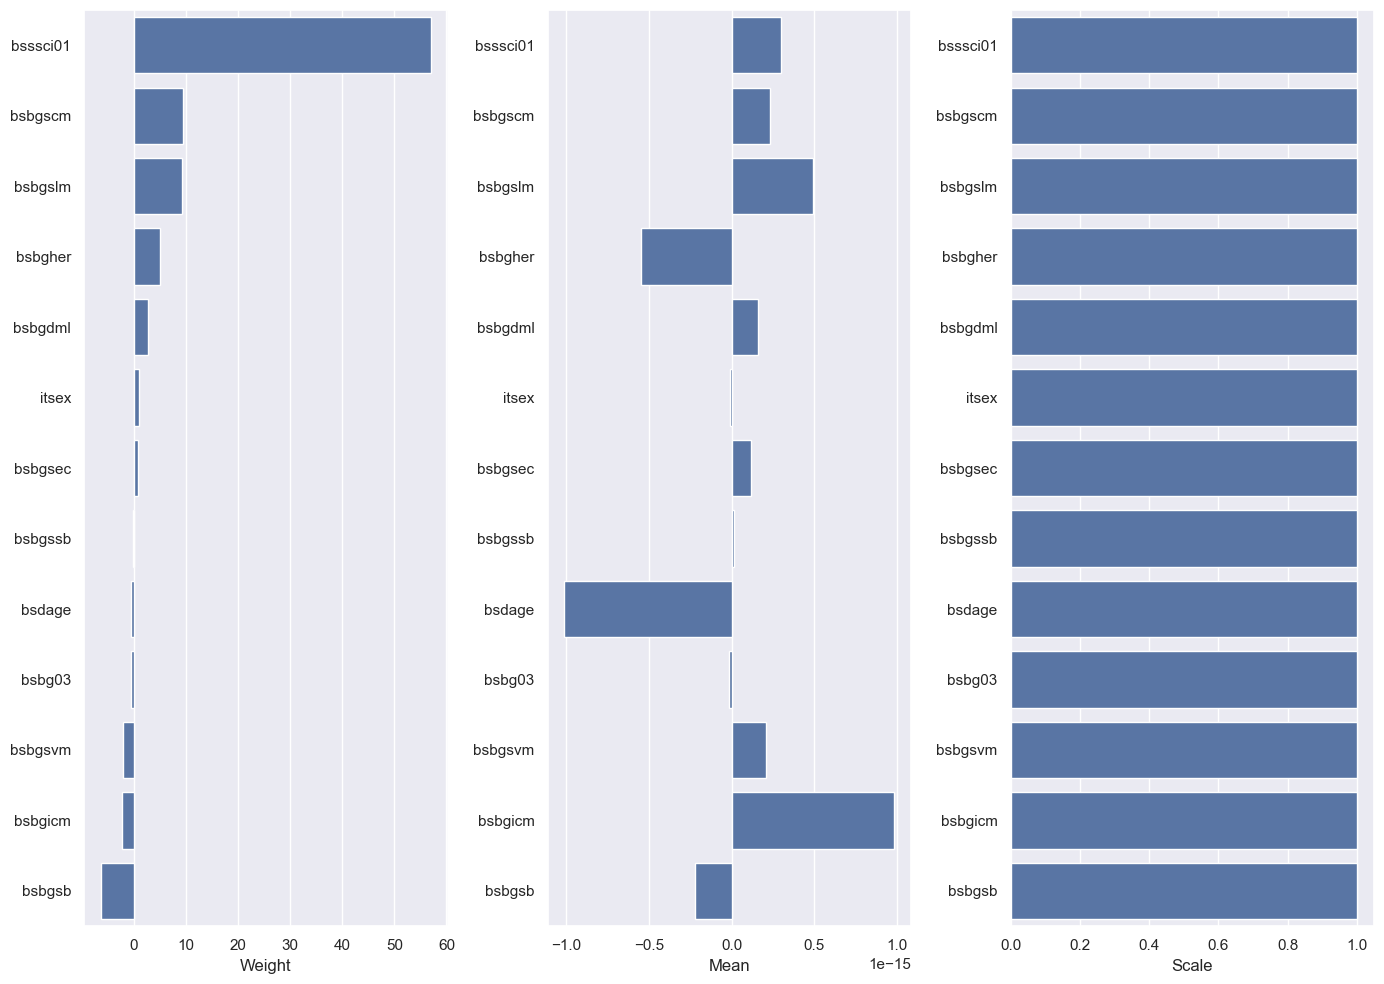

In [340]:
show_weights(numeric_features, ridge2.coef_, means, scales)

### 11.2. Lasso regression ($L_1$ regularisation)

Lasso uses the **absolute values** of coefficients as the penalty:

$$L_{\text{Lasso}} = \sum_{i=1}^{N}(y_i - \hat{y}_i)^2 + \alpha \cdot \sum_{j=1}^{k} \lvert w_j \rvert$$

The key difference from Ridge: Lasso can shrink coefficients **exactly to zero**, effectively performing **feature selection**. Features that contribute weakly are dropped entirely.

| | Ridge ($L_2$) | Lasso ($L_1$) |
|---|---|---|
| Penalty | $\alpha \sum w_j^2$ | $\alpha \sum \lvert w_j \rvert$ |
| Coefficients | Shrunk, never zero | Can be exactly zero |
| Feature selection | No | Yes |
| Best when | Many features contribute | Few features dominate |

In [341]:
from sklearn.linear_model import Lasso

lasso = Lasso().fit(X_train_scaled, y_train)
y_test_pred = lasso.predict(X_test_scaled)
y_train_pred = lasso.predict(X_train_scaled)

print('Train RMSE = %.4f' % np.sqrt(mean_squared_error(y_train, y_train_pred)))
print('Test RMSE  = %.4f' % np.sqrt(mean_squared_error(y_test, y_test_pred)))
print(f'N features used: {np.sum(lasso.coef_ != 0)}')

Train RMSE = 45.1801
Test RMSE  = 46.0710
N features used: 7


Best alpha = 1.1288


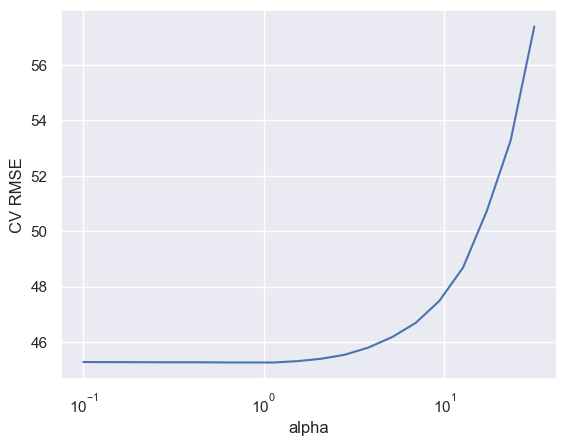

In [342]:
alphas = np.logspace(-1, 1.5, 20)
searcher = GridSearchCV(Lasso(),
                        {'alpha': alphas},
                        scoring='neg_root_mean_squared_error',
                        cv=10)
searcher.fit(X_train_scaled, y_train)

best_alpha = searcher.best_params_['alpha']
print(f'Best alpha = {best_alpha:.4f}')

plt.plot(alphas, -searcher.cv_results_['mean_test_score'])
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('CV RMSE');

In [343]:
lasso2 = Lasso(alpha=best_alpha).fit(X_train_scaled, y_train)
y_test_pred = lasso2.predict(X_test_scaled)
y_train_pred = lasso2.predict(X_train_scaled)

print('Train RMSE = %.4f' % np.sqrt(mean_squared_error(y_train, y_train_pred)))
print('Test RMSE  = %.4f' % np.sqrt(mean_squared_error(y_test, y_test_pred)))
print(f'N features used: {np.sum(lasso2.coef_ != 0)}')

Train RMSE = 45.1971
Test RMSE  = 46.0689
N features used: 6


In [344]:
lasso2.coef_

array([-0.        ,  0.        , -0.        , 56.74160644,  4.43910008,
       -0.        , -4.58080629,  6.54747823, -0.        ,  0.93124646,
        8.62646868, -0.        ,  0.        ])

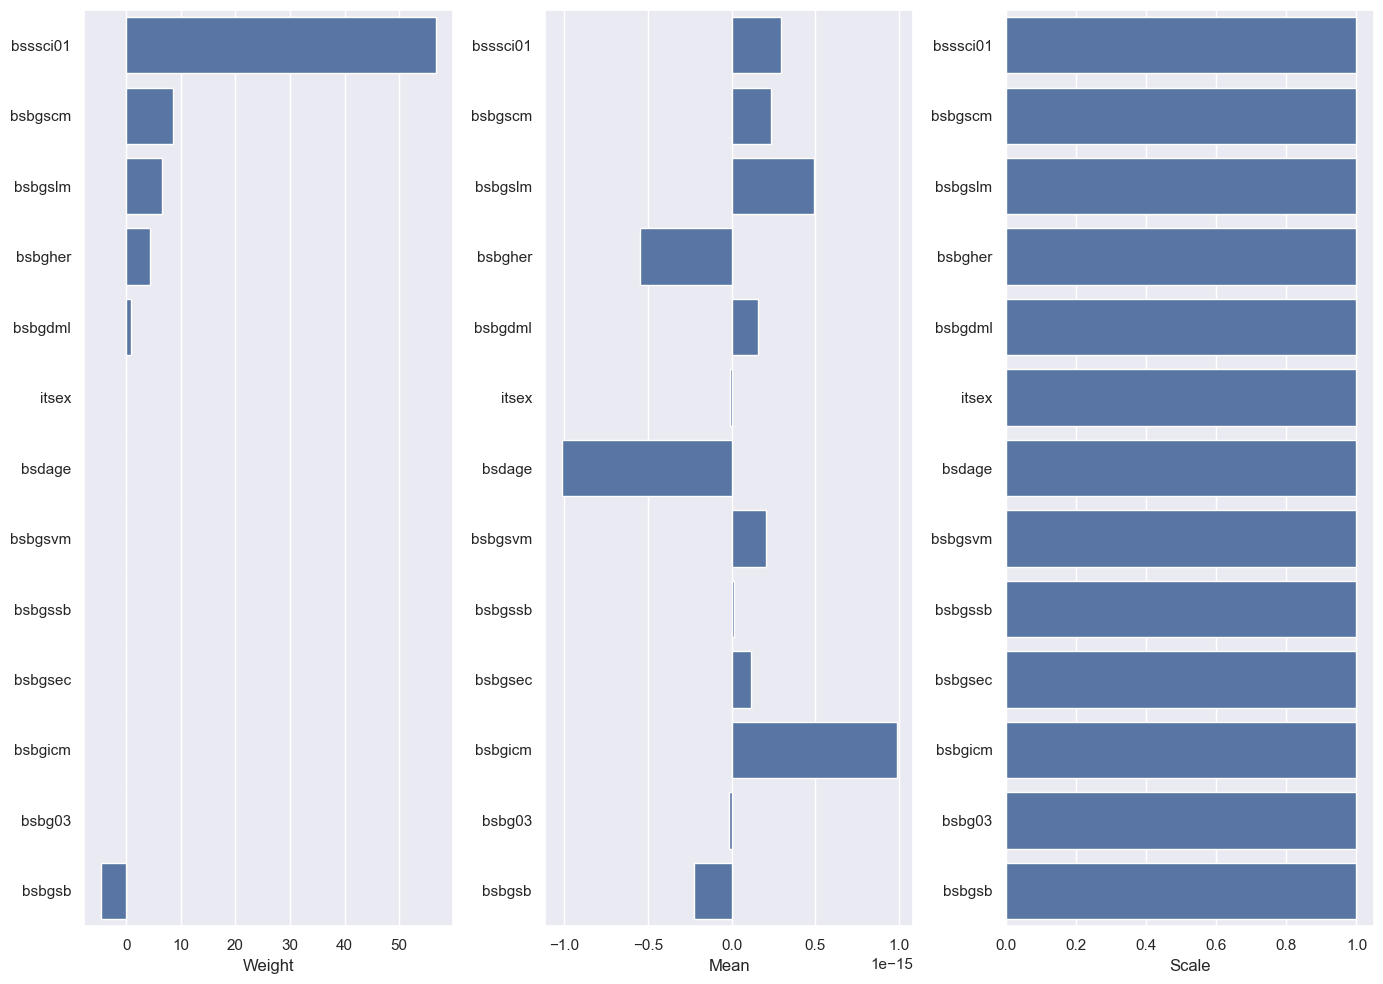

In [345]:
show_weights(numeric_features, lasso2.coef_, means, scales)

### Regularisation + polynomial features

Regularisation is especially useful with polynomial features where the model has many parameters and is prone to overfitting.

In [346]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

poly_names = poly.get_feature_names_out(input_features=numeric_features)
print(f'Number of features: {X_train_poly.shape[1]}')

Number of features: 104


In [347]:
lr_p = LinearRegression().fit(X_train_poly, y_train)
y_train_pred = lr_p.predict(X_train_poly)
y_test_pred = lr_p.predict(X_test_poly)

print('OLS on polynomial features:')
print('Train RMSE = %.4f' % np.sqrt(mean_squared_error(y_train, y_train_pred)))
print('Test RMSE  = %.4f' % np.sqrt(mean_squared_error(y_test, y_test_pred)))

OLS on polynomial features:
Train RMSE = 43.8524
Test RMSE  = 47.0218


Best Ridge alpha = 88.5867


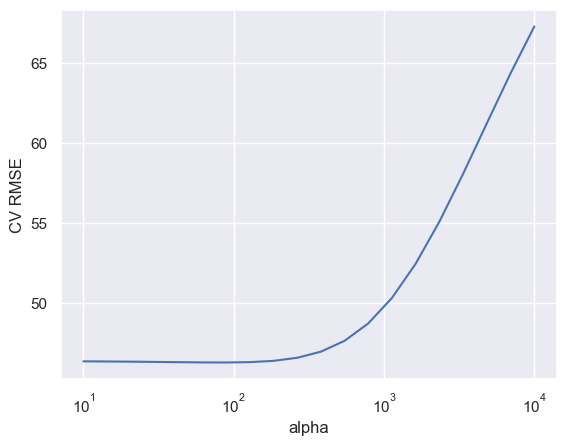

In [348]:
alphas = np.logspace(1, 4, 20)
searcher = GridSearchCV(Ridge(),
                        {'alpha': alphas},
                        scoring='neg_root_mean_squared_error',
                        cv=10)
searcher.fit(X_train_poly, y_train)

best_alpha = searcher.best_params_['alpha']
print(f'Best Ridge alpha = {best_alpha:.4f}')

plt.plot(alphas, -searcher.cv_results_['mean_test_score'])
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('CV RMSE');

In [349]:
ridge_p = Ridge(best_alpha).fit(X_train_poly, y_train)
y_test_pred = ridge_p.predict(X_test_poly)
y_train_pred = ridge_p.predict(X_train_poly)

print('Ridge on polynomial features:')
print('Train RMSE = %.4f' % np.sqrt(mean_squared_error(y_train, y_train_pred)))
print('Test RMSE  = %.4f' % np.sqrt(mean_squared_error(y_test, y_test_pred)))

Ridge on polynomial features:
Train RMSE = 43.9281
Test RMSE  = 46.8702


Best Lasso alpha = 1.6681


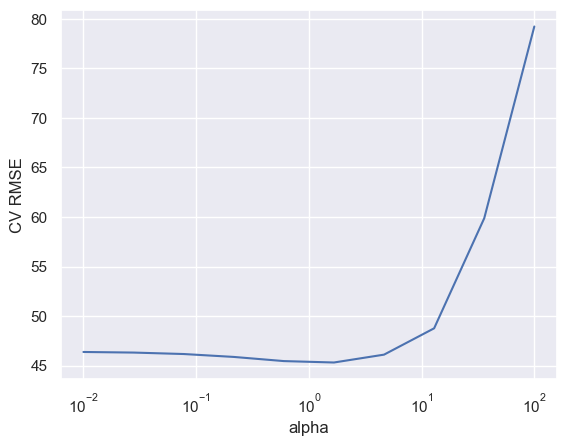

In [350]:
alphas = np.logspace(-2, 2, 10)
searcher = GridSearchCV(Lasso(),
                        {'alpha': alphas},
                        scoring='neg_root_mean_squared_error',
                        cv=10)
searcher.fit(X_train_poly, y_train)

best_alpha = searcher.best_params_['alpha']
print(f'Best Lasso alpha = {best_alpha:.4f}')

plt.plot(alphas, -searcher.cv_results_['mean_test_score'])
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('CV RMSE');

In [351]:
lasso_p = Lasso(best_alpha).fit(X_train_poly, y_train)
y_test_pred = lasso_p.predict(X_test_poly)
y_train_pred = lasso_p.predict(X_train_poly)

print('Lasso on polynomial features:')
print('Train RMSE = %.4f' % np.sqrt(mean_squared_error(y_train, y_train_pred)))
print('Test RMSE  = %.4f' % np.sqrt(mean_squared_error(y_test, y_test_pred)))
print(f'N features used: {np.sum(lasso_p.coef_ != 0)}')

Lasso on polynomial features:
Train RMSE = 44.9215
Test RMSE  = 45.9616
N features used: 18


In [352]:
for e in sorted(list(zip(list(poly_names), lasso_p.coef_)),
                key=lambda e: -abs(e[1])):
    if e[1] != 0:
        print(f'\t{e[0]}, {e[1]:.3f}')

	bsssci01, 56.116
	bsbgscm, 8.301
	bsbgslm, 6.389
	bsbgher, 4.033
	bsbgsb, -3.689
	bsssci01 bsbgssb, 1.146
	bsdage bsbgsb, 1.083
	bsbg03 bsbgssb, -0.789
	bsbgsec^2, -0.769
	bsbgher bsbgssb, -0.766
	bsssci01 bsbgsvm, 0.762
	bsbg03 bsbgher, 0.613
	bsdage^2, -0.592
	bsbgssb bsbgscm, -0.368
	bsssci01 bsbgscm, 0.327
	bsbg03 bsbgicm, -0.302
	bsbgdml, 0.279
	bsbgsb bsbgdml, -0.211


## 12. Analysis with categorical variables

So far we dropped the categorical features (`bsdgedup`, `bsbg04`). Now let's include them.

Linear regression requires numeric inputs. For categorical variables we use **one-hot encoding (OHE)**: create a binary (0/1) column for each category.

With $k$ categories we create $k-1$ dummy columns (dropping one to avoid perfect collinearity — this is the `drop='first'` parameter).

We also need to handle missing values in numeric features — we'll use **mean imputation** via `SimpleImputer`.

**Reload and recode the data** (fresh start for the full pipeline).

In [353]:
students = pd.read_spss('bsgrusm7.sav',
                       usecols=['IDSTUD', 'BSMMAT01', 'BSSSCI01', 'ITSEX', 'BSDAGE', 'BSBGHER',
                                'BSBGSSB', 'BSBGSB', 'BSBGICM', 'BSBGSLM', 'BSBGSVM', 'BSBGDML',
                                'BSBGSCM', 'BSBGSEC', 'BSDGEDUP', 'BSBG03', 'BSBG04'],
                       convert_categoricals=False)
students.rename(str.lower, axis='columns', inplace=True)

students.itsex.replace({2: 0}, inplace=True)
students.bsbg03.replace({2: 0, 3: 0, 4: 0}, inplace=True)
students.bsdgedup.replace({6: np.nan, 5: 'secondary', 4: 'secondary',
                           3: 'secondary', 2: 'postsecondary', 1: 'higher'}, inplace=True)
students.bsbg04.replace({1: 'books0_10', 2: 'books11_25', 3: 'books26_100',
                         4: 'books101_200', 5: 'books200more'}, inplace=True)

**Fill missing values** — categorical with a special label, numeric with the mean.

In [354]:
students.bsdgedup.fillna('unknown', inplace=True)
students.bsbg04.fillna('books11_25', inplace=True)

numeric_features = ['bsbg03', 'bsdage', 'bsssci01', 'bsbgher',
                    'bsbgssb', 'bsbgsb', 'bsbgslm', 'bsbgicm',
                    'bsbgdml', 'bsbgscm', 'bsbgsvm', 'bsbgsec']

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
students[numeric_features] = imputer.fit_transform(students[numeric_features])
students.isna().sum().sum()

np.int64(0)

**Apply one-hot encoding** to categorical variables.

In [355]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, drop='first')
df_ohe = pd.DataFrame(ohe.fit_transform(students[['bsdgedup', 'bsbg04']]))
df_ohe.columns = ohe.get_feature_names_out()

students = df_ohe.join(students)
students.drop(columns=['bsdgedup', 'bsbg04', 'idstud'], inplace=True)
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3901 entries, 0 to 3900
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   bsdgedup_postsecondary  3901 non-null   float64
 1   bsdgedup_secondary      3901 non-null   float64
 2   bsdgedup_unknown        3901 non-null   float64
 3   bsbg04_books101_200     3901 non-null   float64
 4   bsbg04_books11_25       3901 non-null   float64
 5   bsbg04_books200more     3901 non-null   float64
 6   bsbg04_books26_100      3901 non-null   float64
 7   bsbg03                  3901 non-null   float64
 8   itsex                   3901 non-null   float64
 9   bsdage                  3901 non-null   float64
 10  bsmmat01                3901 non-null   float64
 11  bsssci01                3901 non-null   float64
 12  bsbgher                 3901 non-null   float64
 13  bsbgssb                 3901 non-null   float64
 14  bsbgsb                  3901 non-null   

**Split, scale, fit, and evaluate.**

In [356]:
X = students.drop(columns='bsmmat01')
y = students.bsmmat01

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)
X_train.shape, X_test.shape

((2730, 20), (1171, 20))

In [357]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

> **Note:** here we scaled all features including the binary dummies. Strictly speaking, scaling binary features is unnecessary (they are already on a 0/1 scale). In your homework, try scaling **numeric features only** and compare.

In [358]:
ols = LinearRegression().fit(X_train_scaled, y_train)
y_train_pred = ols.predict(X_train_scaled)
y_test_pred = ols.predict(X_test_scaled)

print('Train:')
metrics(y_train, y_train_pred)
print('\nTest:')
metrics(y_test, y_test_pred)

Train:
MAE  = 35.542
MSE  = 2028.744
RMSE = 45.042
R²   = 0.700

Test:
MAE  = 36.923
MSE  = 2147.890
RMSE = 46.345
R²   = 0.668


**Show coefficients** — which features matter most?

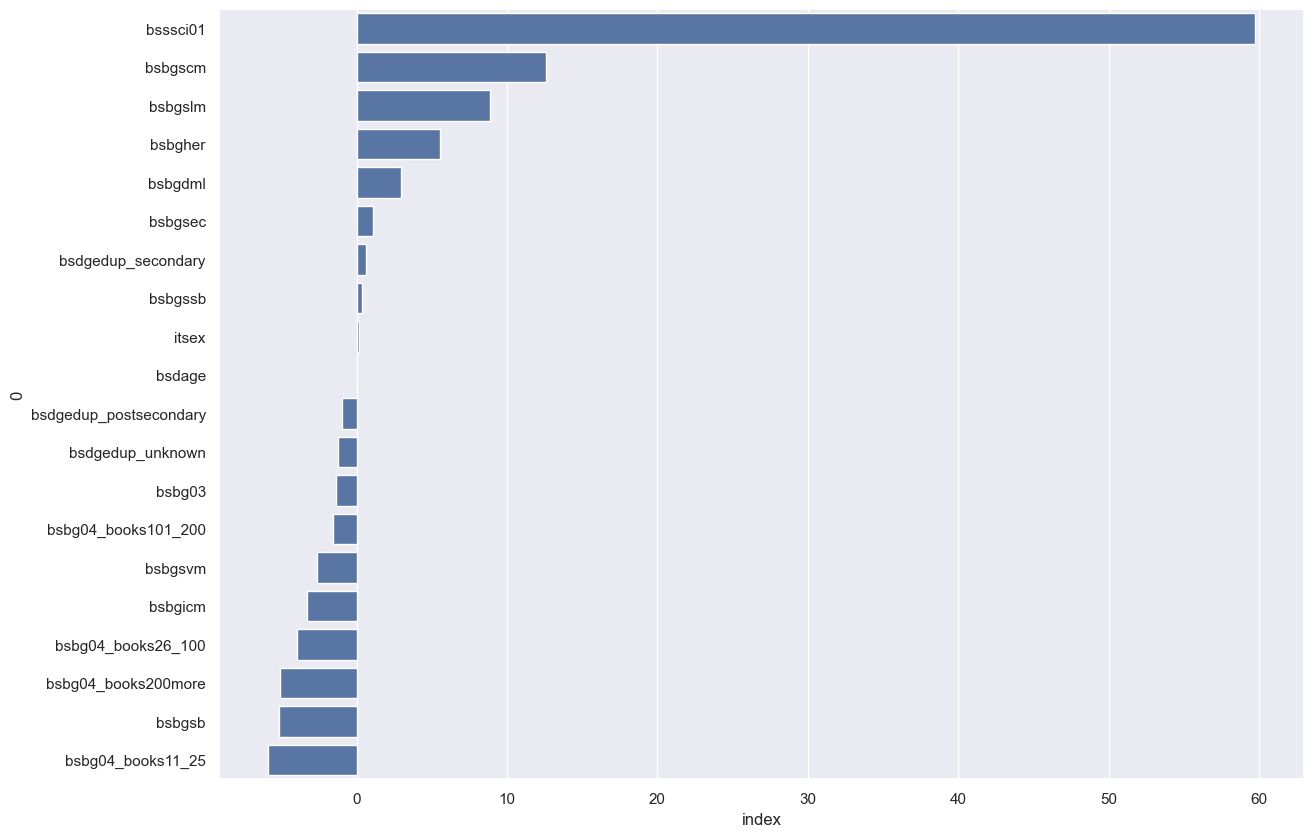

In [359]:
a = pd.DataFrame(X.columns, list(ols.coef_)).sort_index(ascending=False).reset_index()
plt.figure(figsize=(14, 10))
sns.barplot(y=a.iloc[:, -1], x=a.iloc[:, 0]);

**Fit Lasso** to see which features get selected.

In [360]:
lasso = Lasso().fit(X_train_scaled, y_train)
y_train_pred = lasso.predict(X_train_scaled)
y_test_pred = lasso.predict(X_test_scaled)

print('Train:')
metrics(y_train, y_train_pred)
print('\nTest:')
metrics(y_test, y_test_pred)

Train:
MAE  = 35.757
MSE  = 2050.815
RMSE = 45.286
R²   = 0.696

Test:
MAE  = 36.858
MSE  = 2129.475
RMSE = 46.146
R²   = 0.671


In [361]:
for e in sorted(list(zip(list(X.columns), lasso.coef_)),
                key=lambda e: -abs(e[1])):
    if e[1] != 0:
        print(f'\t{e[0]}, {e[1]:.3f}')

	bsssci01, 59.163
	bsbgscm, 11.834
	bsbgslm, 6.398
	bsbgsb, -3.597
	bsbg04_books11_25, -2.436
	bsbg04_books101_200, 1.613
	bsbgher, 1.547
	bsbgdml, 1.517
	bsbgicm, -1.119
	bsdgedup_unknown, -0.513
	bsbgsvm, -0.472
	bsbg03, -0.347
	bsbgsec, 0.123
	bsdgedup_postsecondary, -0.117


---
# Seminar Assignment

Work independently. Apply the regression techniques from the lecture to a new dataset.

**Dataset:** `diamonds` from seaborn — characteristics and prices of ~54,000 round-cut diamonds. 10 variables: `carat`, `cut`, `color`, `clarity`, `depth`, `table`, `price`, `x`, `y`, `z`.

Load with:
```python
import seaborn as sns
df = sns.load_dataset('diamonds')
```

**Your target:** `price` (in USD).

Variables:
- `carat` — weight of the diamond
- `cut` — quality of the cut (Fair, Good, Very Good, Premium, Ideal)
- `color` — diamond colour (J worst to D best)
- `clarity` — clarity grade (I1 worst to IF best)
- `depth` — total depth percentage
- `table` — width of top relative to widest point
- `x`, `y`, `z` — dimensions in mm

## Task 1. Load and explore

1. Load the `diamonds` dataset. Print `.info()` and `.describe()`. How many observations and how many variables?
2. Plot the distribution of `price`. Is it skewed? Try a log-transform (`np.log(price)`) — does it look more symmetric?
3. Plot the correlation of numeric features with `price`. Which feature correlates most strongly? Show a scatter plot of that feature against `price`.

In [371]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Your code here

df = sns.load_dataset('diamonds')

## Task 2. Baseline linear regression

1. Using only the **numeric** features (`carat`, `depth`, `table`, `x`, `y`, `z`), fit a `LinearRegression` model on the full dataset to predict `price`.
2. Report **MAE, MSE, RMSE, and R²** on the training data.
3. Interpret the coefficient on `carat`: in plain English, what does its value mean in USD per unit of carat?

In [ ]:
# Your code here
from sklearn.linear_model import LinearRegression
X = df[['carat', 'depth', 'table', 'x', 'y', 'z']]
y = df['price']

lr = LinearRegression().fit(X, y)
y_pred = lr.predict(X)


np.float64(10686.309080631094)

## Task 3. Residual analysis

1. For the model from Task 2, plot three diagnostic charts side-by-side: residuals vs predicted, histogram of residuals, QQ-plot.
2. Do you see **heteroscedasticity** (a funnel shape) or **non-linearity** (a curved pattern)? Describe what you see.
3. Refit the model with `np.log(price)` as the target instead of raw `price`. Redraw the three plots. Did the diagnostics improve? Briefly explain why a log transform can help here.

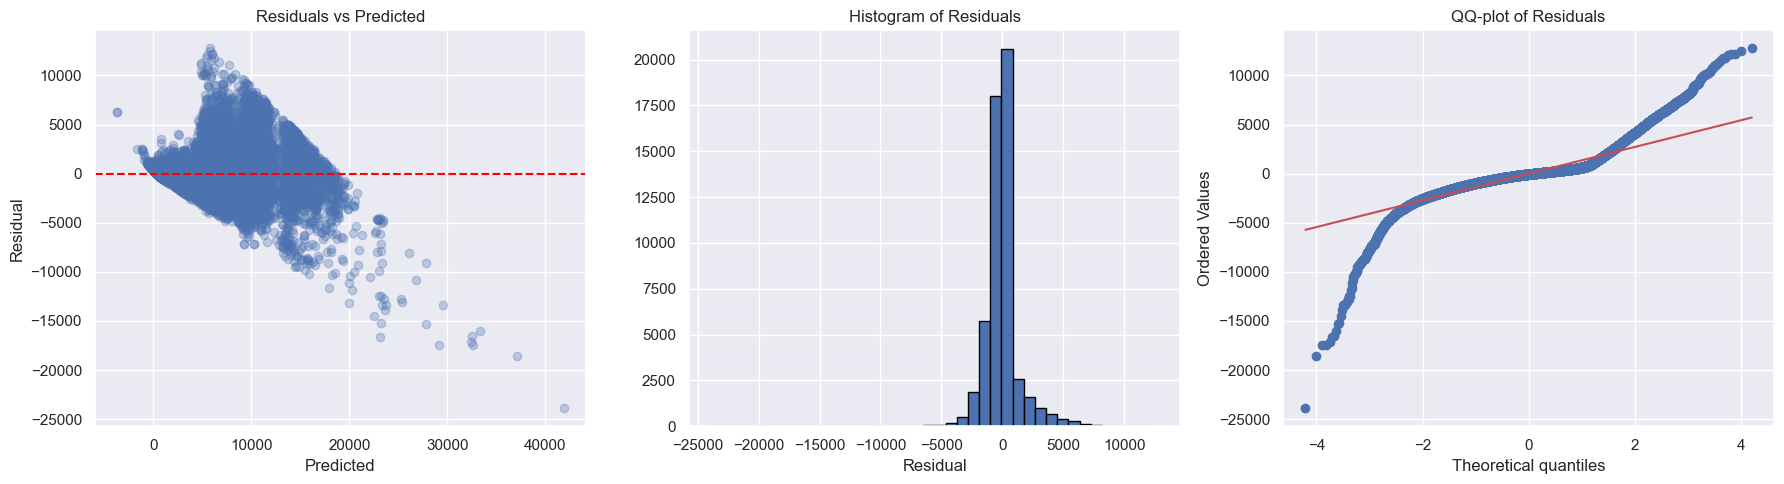

In [373]:
# Your code here

residuals = y - y_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Residuals vs Predicted
axes[0].scatter(y_pred, residuals, alpha=0.3)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted')

# 2. Histogram of residuals
axes[1].hist(residuals, bins=40, edgecolor='black')
axes[1].set_xlabel('Residual')
axes[1].set_title('Histogram of Residuals')

# 3. QQ-plot
from scipy import stats
stats.probplot(residuals, dist='norm', plot=axes[2])
axes[2].set_title('QQ-plot of Residuals')

plt.tight_layout()
plt.show()

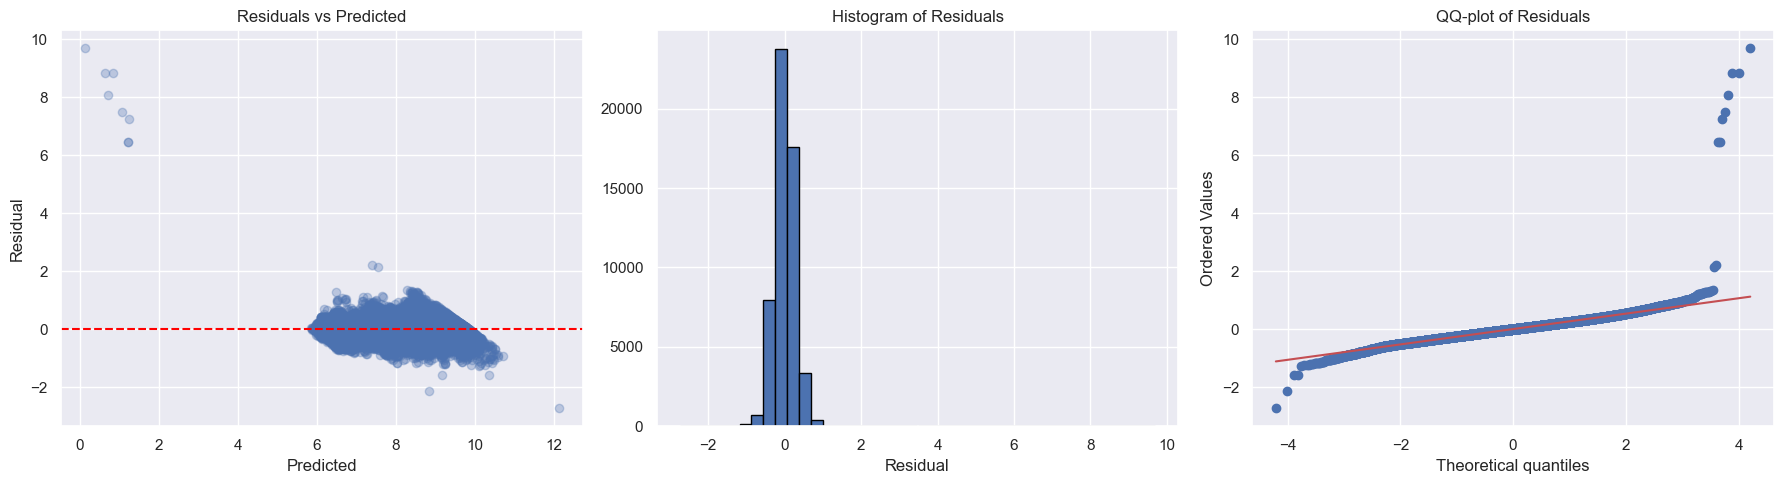

In [ ]:
# Re-estimate the model with a logged price:
from sklearn.linear_model import LinearRegression
X = df[['carat', 'depth', 'table', 'x', 'y', 'z']]
y = np.log(df['price'])

lr = LinearRegression().fit(X, y)
y_pred = lr.predict(X)

# New graphs:

residuals = y - y_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Residuals vs Predicted
axes[0].scatter(y_pred, residuals, alpha=0.3)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted')

# 2. Histogram of residuals
axes[1].hist(residuals, bins=40, edgecolor='black')
axes[1].set_xlabel('Residual')
axes[1].set_title('Histogram of Residuals')

# 3. QQ-plot
from scipy import stats
stats.probplot(residuals, dist='norm', plot=axes[2])
axes[2].set_title('QQ-plot of Residuals')

plt.tight_layout()
plt.show()

<Axes: xlabel='price', ylabel='Count'>

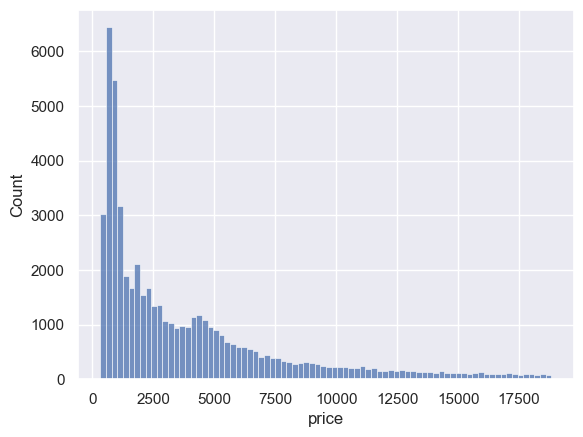

In [376]:
sns.histplot(df['price'])

<Axes: xlabel='price', ylabel='Count'>

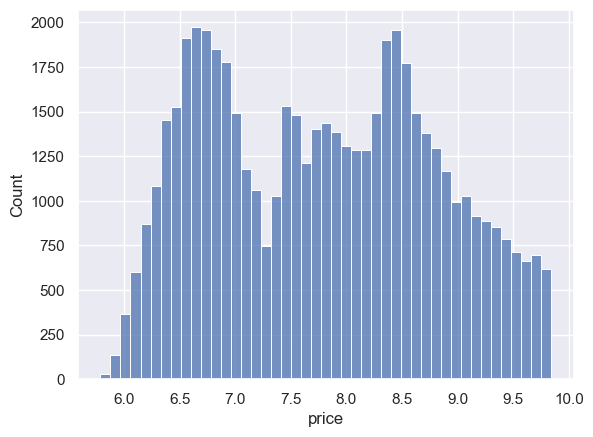

In [377]:
sns.histplot(np.log(df['price']))

## Task 4. Multicollinearity

1. Compute **VIF** for all numeric features (`carat`, `depth`, `table`, `x`, `y`, `z`). Which features are the biggest offenders?
2. Explain in one sentence *why* `x`, `y`, `z` have high VIF (hint: think about the geometry of a diamond).
3. Drop the worst offenders (or combine them — your choice) and refit the model. How did the coefficients on the *remaining* features change? Did the test RMSE get worse?

In [382]:
# Your code here
from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression

X = df[['carat', 'depth', 'table', 'x', 'y', 'z']]
y = np.log(df['price'])

lr = LinearRegression().fit(X, y)
y_pred = lr.predict(X)
print(f'RMSE: {root_mean_squared_error(y, y_pred)}')
print(f'MAE: {mean_absolute_error(y, y_pred)}')
print(f'MSE: {mean_squared_error(y, y_pred)}')

# To estimate VIF:

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data.sort_values('VIF', ascending=False).round(2)

RMSE: 0.2794935026173757
MAE: 0.20457358894178027
MSE: 0.078116618005329


,feature,VIF
3,x,1284.95
5,z,540.68
4,y,531.00
1,depth,515.15
2,table,500.60
0,carat,70.13


In [ ]:
X = df[['carat', 'depth', 'table']]
y = np.log(df['price'])

lr = LinearRegression().fit(X, y)
y_pred = lr.predict(X)
print(f'RMSE: {root_mean_squared_error(y, y_pred)}')
print(f'MAE: {mean_absolute_error(y, y_pred)}')
print(f'MSE: {mean_squared_error(y, y_pred)}')


vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data.sort_values('VIF', ascending=False).round(2)

RMSE: 0.3959420920716002
MAE: 0.30520357071670934
MSE: 0.15677014027403552


,feature,VIF
2,table,396.89
1,depth,389.41
0,carat,3.93


In [386]:
df["size"] = df['x']*df['y']*df['z']
X = df[['depth', 'table', "size"]]
y = np.log(df['price'])

lr = LinearRegression().fit(X, y)
y_pred = lr.predict(X)
print(f'RMSE: {root_mean_squared_error(y, y_pred)}')
print(f'MAE: {mean_absolute_error(y, y_pred)}')
print(f'MSE: {mean_squared_error(y, y_pred)}')


vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data.sort_values('VIF', ascending=False).round(2)

RMSE: 0.44130606098423175
MAE: 0.3132126311597249
MSE: 0.19475103946141847


,feature,VIF
1,table,396.56
0,depth,389.34
2,size,3.84


## Task 5. Train/test split and cross-validation

1. Split the data into train (70%) and test (30%) with `random_state=42`. Fit `LinearRegression` on the training set and report RMSE on both train and test.
2. Run **10-fold cross-validation** on the training set with `neg_root_mean_squared_error`. Report the mean CV RMSE.
3. Compare the three numbers (train, test, mean CV). Is there overfitting? How close is the CV estimate to the actual test score?

In [366]:
# Your code here

## Task 6. Polynomial features and regularisation

1. Standardise the numeric features with `StandardScaler`. Add polynomial features of `degree=2` using `PolynomialFeatures`. How many features do you have now?
2. Fit three models on the polynomial features: plain OLS, **Ridge** (tune `alpha` with `GridSearchCV`, 10-fold), and **Lasso** (same). Report test RMSE for each.
3. How many features did Lasso keep non-zero? Which one performed best on the test set, and does that match what you would expect from the bias–variance tradeoff?

In [367]:
# Your code here

## Task 7. Categorical features and final model

1. Apply **one-hot encoding** to `cut`, `color`, and `clarity` (use `drop='first'`). How many dummy columns did you end up with?
2. Combine the scaled numeric features with the one-hot-encoded categorical features. Fit a final model of your choice (OLS, Ridge, or Lasso with tuned `alpha`) and report train and test RMSE.
3. Show the **top 10 features** by absolute coefficient value. Which features are the strongest predictors of diamond price — do they match your domain intuition?
4. *(Bonus)* Refit the entire pipeline with `np.log(price)` as the target. Does the log-target model give a better test RMSE when you transform predictions back with `np.exp(...)` before computing RMSE?

In [368]:
# Your code here